# Notebook 2 — Exploring the Face Data (FER2013)

In this notebook we will:
- Look at how many face images we have per emotion
- Actually see what the face images look like
- Understand how we group emotions into interview labels
- See how images look after preprocessing (resizing, grayscale)


## Step 1 — Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import random

print('All libraries loaded!')

All libraries loaded!


## Step 2 — Count Images Per Emotion

Let's see how many images we have for each emotion folder.

In [2]:
# How we map FER emotions to interview labels
INTERVIEW_MAP = {
    'angry':    'Nervous',
    'disgust':  'Nervous',
    'fear':     'Nervous',
    'happy':    'Confident',
    'neutral':  'Neutral',
    'sad':      'Nervous',
    'surprise': 'Confident'
}

TRAIN_DIR = '../data/raw/fer/images/images/train'

emotion_counts = {}
interview_counts = {'Nervous': 0, 'Neutral': 0, 'Confident': 0}

for emotion in os.listdir(TRAIN_DIR):
    emotion_dir = os.path.join(TRAIN_DIR, emotion)
    if os.path.isdir(emotion_dir):
        count = len([f for f in os.listdir(emotion_dir) if f.endswith('.jpg')])
        emotion_counts[emotion] = count
        interview_label = INTERVIEW_MAP.get(emotion, 'Neutral')
        interview_counts[interview_label] += count

print('=== Images per Emotion ===')
for emotion, count in sorted(emotion_counts.items()):
    interview = INTERVIEW_MAP.get(emotion, 'Neutral')
    print(f'{emotion:10} : {count:5} images  →  {interview}')

print()
print('=== Images per Interview Label ===')
for label, count in interview_counts.items():
    print(f'{label:10} : {count:5} images')

=== Images per Emotion ===
angry      :  3993 images  →  Nervous
disgust    :   436 images  →  Nervous
fear       :  4103 images  →  Nervous
happy      :  7164 images  →  Confident
neutral    :  4982 images  →  Neutral
sad        :  4938 images  →  Nervous
surprise   :  3205 images  →  Confident

=== Images per Interview Label ===
Nervous    : 13470 images
Neutral    :  4982 images
Confident  : 10369 images


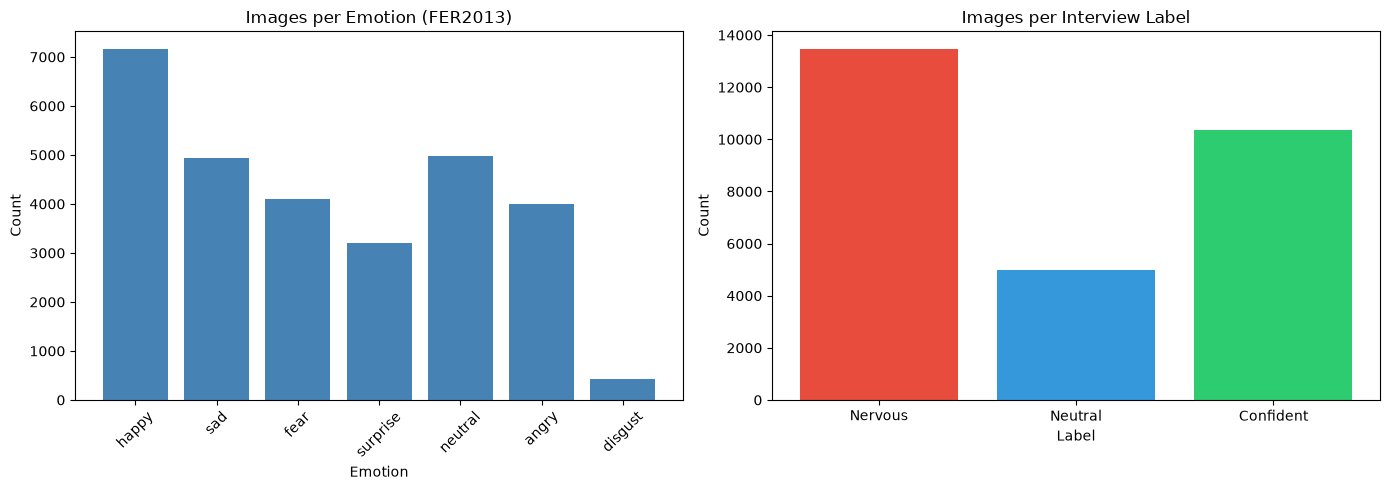

In [3]:
# Visualize as bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per emotion
emotions = list(emotion_counts.keys())
counts = list(emotion_counts.values())
axes[0].bar(emotions, counts, color='steelblue')
axes[0].set_title('Images per Emotion (FER2013)')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Per interview label
colors = ['#e74c3c', '#3498db', '#2ecc71']
axes[1].bar(interview_counts.keys(), interview_counts.values(), color=colors)
axes[1].set_title('Images per Interview Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Step 3 — Look at the Face Images

Let's actually see what these face images look like!

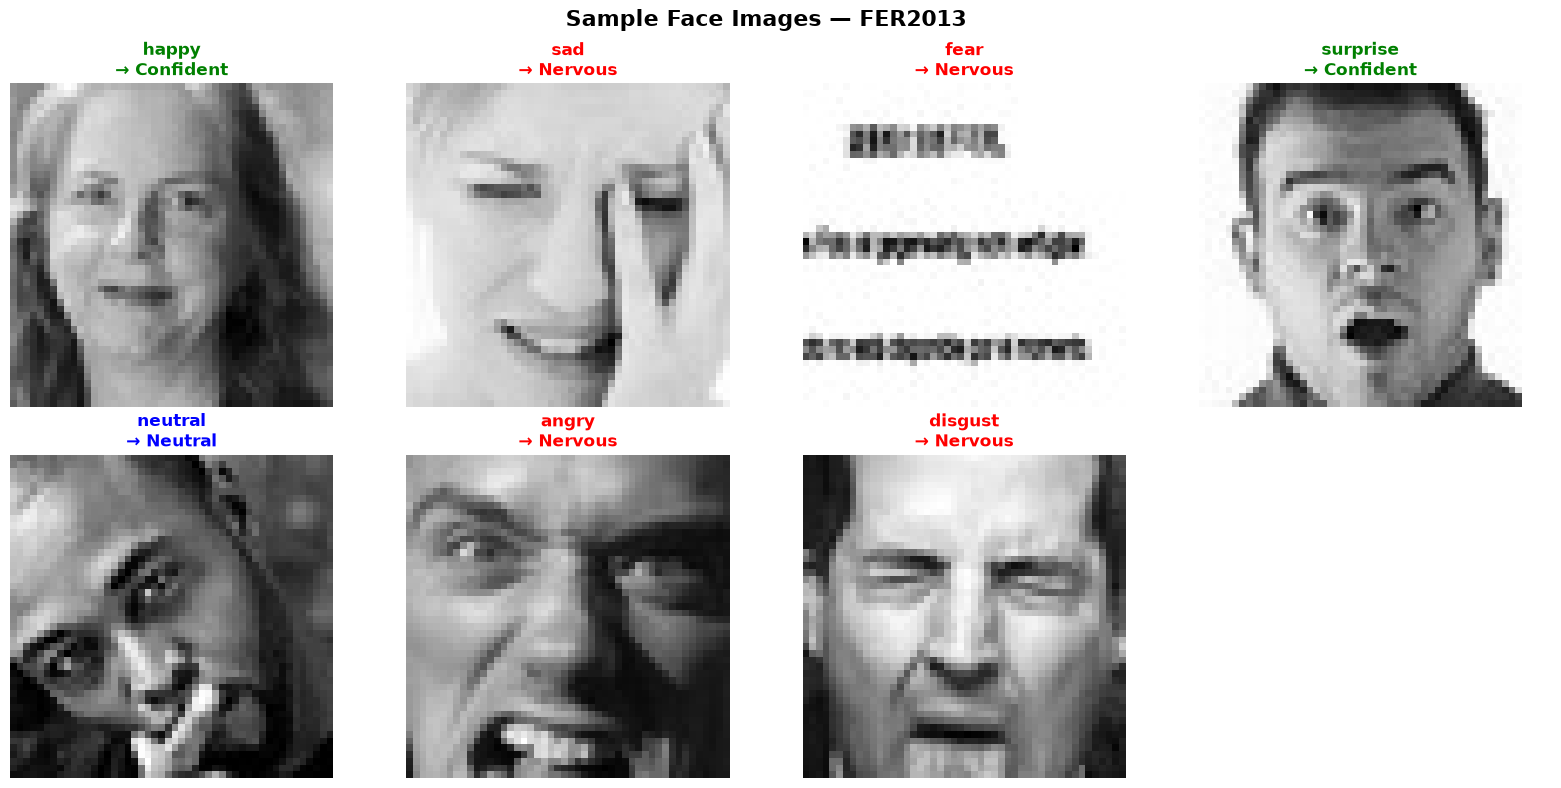

In [4]:
# Show sample images from each emotion
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

emotion_list = list(emotion_counts.keys())

for i, emotion in enumerate(emotion_list):
    emotion_dir = os.path.join(TRAIN_DIR, emotion)
    img_files = [f for f in os.listdir(emotion_dir) if f.endswith('.jpg')]
    
    # Pick a random image
    random_img = random.choice(img_files)
    img_path = os.path.join(emotion_dir, random_img)
    
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    interview_label = INTERVIEW_MAP.get(emotion, 'Neutral')
    color = 'green' if interview_label == 'Confident' else 'red' if interview_label == 'Nervous' else 'blue'
    
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'{emotion}\n→ {interview_label}', color=color, fontweight='bold')
    axes[i].axis('off')

# Hide the last empty subplot if any
for j in range(len(emotion_list), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Face Images — FER2013', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — What Does Preprocessing Do?

Before feeding images to the model, we:
1. Convert to grayscale (remove color — we don't need it)
2. Resize to 48x48 pixels (standard size)
3. Normalize pixel values from 0-255 to 0-1 (makes training faster)

Let's see this in action!

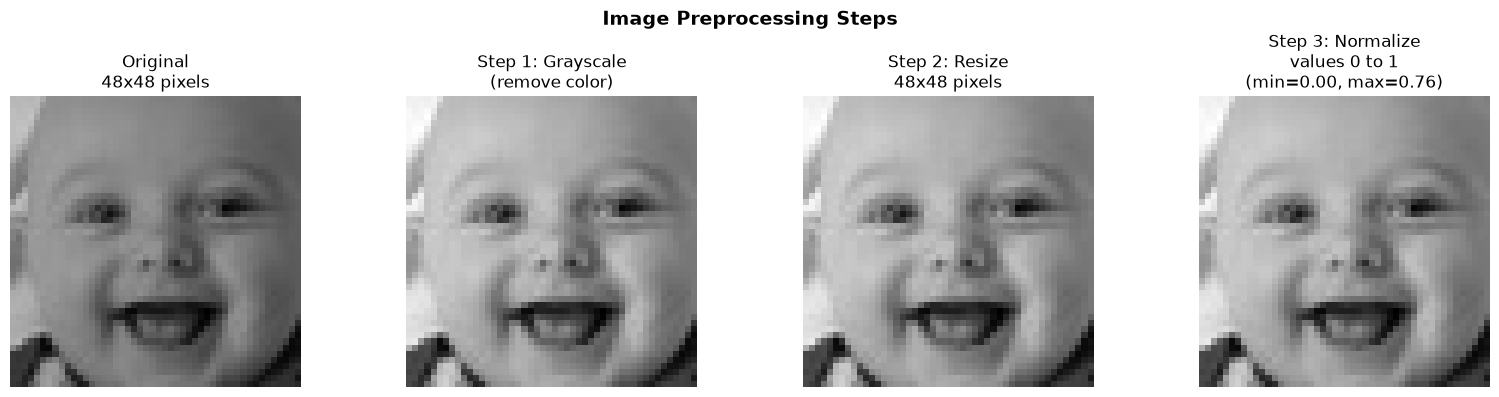

Original pixel values range: 0 to 255
After normalization range: 0.00 to 0.76
Final image shape fed to model: (48, 48, 1)


In [5]:
# Pick one happy image to demonstrate preprocessing
happy_dir = os.path.join(TRAIN_DIR, 'happy')
sample_img_path = os.path.join(happy_dir, os.listdir(happy_dir)[0])

# Original image
original = cv2.imread(sample_img_path)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Step 1: Grayscale
gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

# Step 2: Resize to 48x48
resized = cv2.resize(gray, (48, 48))

# Step 3: Normalize
normalized = resized.astype(np.float32) / 255.0

# Show all steps
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(original_rgb)
axes[0].set_title(f'Original\n{original.shape[1]}x{original.shape[0]} pixels')
axes[0].axis('off')

axes[1].imshow(gray, cmap='gray')
axes[1].set_title('Step 1: Grayscale\n(remove color)')
axes[1].axis('off')

axes[2].imshow(resized, cmap='gray')
axes[2].set_title('Step 2: Resize\n48x48 pixels')
axes[2].axis('off')

axes[3].imshow(normalized, cmap='gray')
axes[3].set_title(f'Step 3: Normalize\nvalues 0 to 1\n(min={normalized.min():.2f}, max={normalized.max():.2f})')
axes[3].axis('off')

plt.suptitle('Image Preprocessing Steps', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Original pixel values range: 0 to 255')
print(f'After normalization range: {normalized.min():.2f} to {normalized.max():.2f}')
print(f'Final image shape fed to model: (48, 48, 1)')

## Step 5 — Show Multiple Samples Per Interview Label

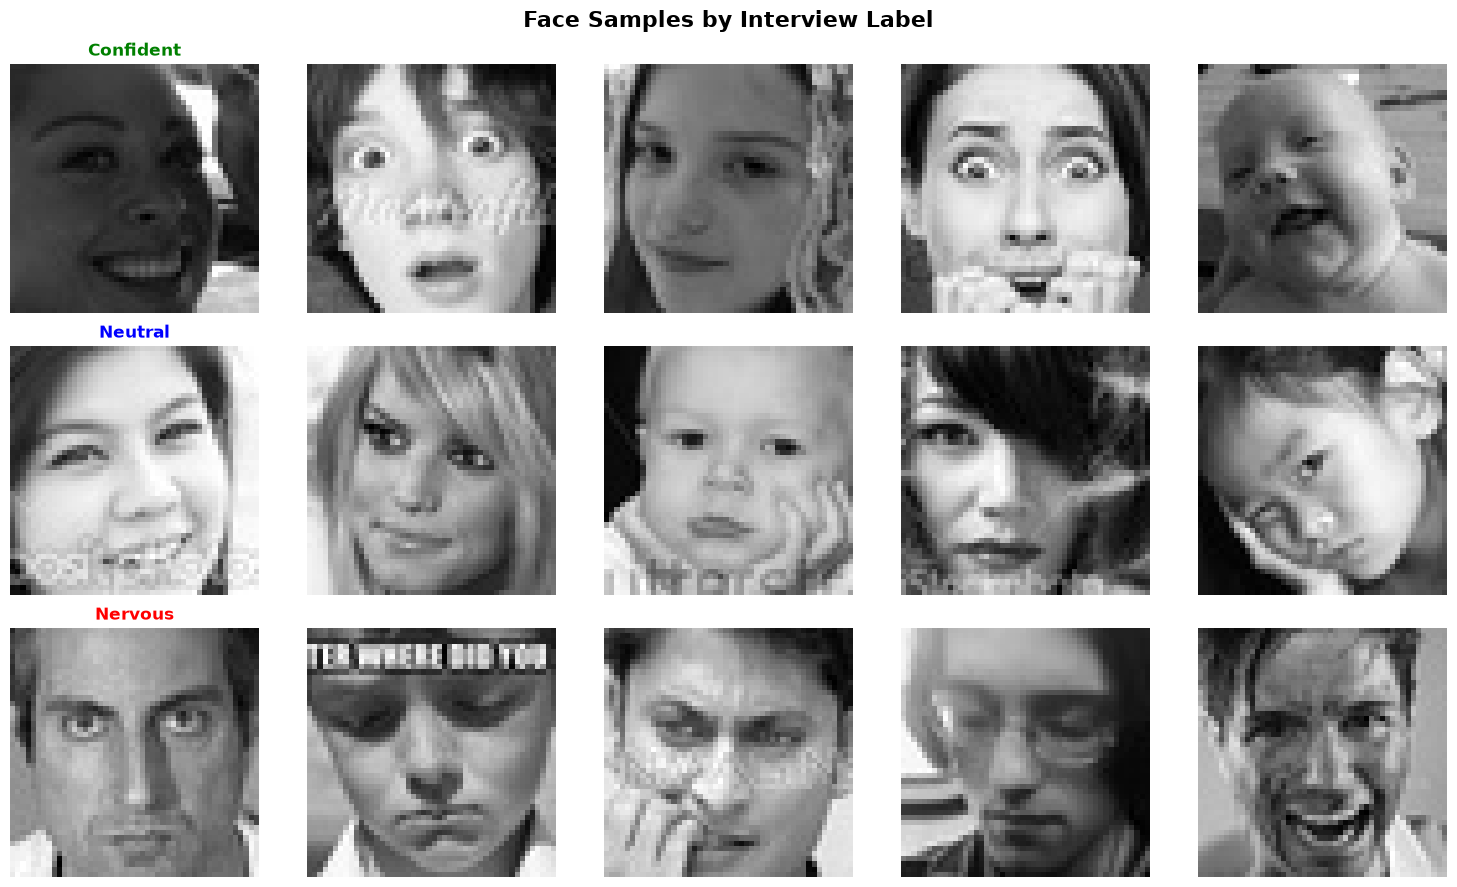

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

label_emotion_map = {
    'Confident': ['happy', 'surprise'],
    'Neutral':   ['neutral'],
    'Nervous':   ['angry', 'fear', 'sad', 'disgust']
}

label_colors = {'Confident': 'green', 'Neutral': 'blue', 'Nervous': 'red'}

for row, (label, source_emotions) in enumerate(label_emotion_map.items()):
    all_images = []
    for emotion in source_emotions:
        emotion_dir = os.path.join(TRAIN_DIR, emotion)
        if os.path.exists(emotion_dir):
            files = [os.path.join(emotion_dir, f) for f in os.listdir(emotion_dir) if f.endswith('.jpg')]
            all_images.extend(files)
    
    sample_images = random.sample(all_images, min(5, len(all_images)))
    
    for col, img_path in enumerate(sample_images):
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (48, 48))
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(label, color=label_colors[label], fontweight='bold', fontsize=12)

plt.suptitle('Face Samples by Interview Label', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary

What we learned in this notebook:
- We have 71,774 face images total
- 7 emotion categories → grouped into 3 interview labels
- Images are 48x48 grayscale pixels after preprocessing
- Pixel values are normalized from 0-255 to 0-1
- The CNN model will learn visual patterns that separate Confident, Neutral and Nervous faces

Next step: Process all audio files into MFCC features and train the Speech Confidence model!